# 1. Libraries & Data Loading

We import the required data analysis and visualization libraries, load the unemployment dataset, and clean whitespace from column headers.

In [8]:
# ===================================================
# 1. LIBRARIES & DATA LOADING
# ===================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Unemployment in India.csv")

# Clean column headers
df.columns = df.columns.str.strip()

# View first 5 rows
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# 2. Data Cleaning & Preprocessing

We remove missing values, convert the Date column to proper date format, and extract Year and Month for time analysis.

In [10]:
# ===================================================
# 2. DATA CLEANING & PREPROCESSING
# ===================================================
# Remove null values
df = df.dropna()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create Year and Month columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# Check dataset info
df.info()
import warnings
warnings.filterwarnings('ignore')

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
 7   Year                                     740 non-null    int32         
 8   Month                                    740 non-null    str           
dtypes: datetime64[us](1), float64(3), int32(1), str(4)
memory us

# 3. Unemployment Rate Over Time

We plot the unemployment rate over time to see how national trends changed throughout the dataset period.

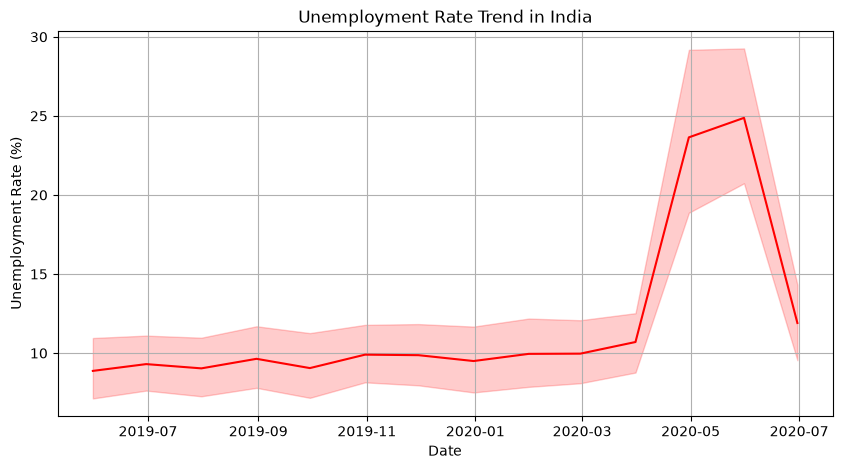

In [11]:
# ===================================================
# 3. UNEMPLOYMENT RATE OVER TIME
# ===================================================
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date', y='Estimated Unemployment Rate (%)', color='red')

plt.title('Unemployment Rate Trend in India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()

# 4. State-wise Unemployment Analysis

We aggregate the data to calculate and compare the average unemployment rate across different states.

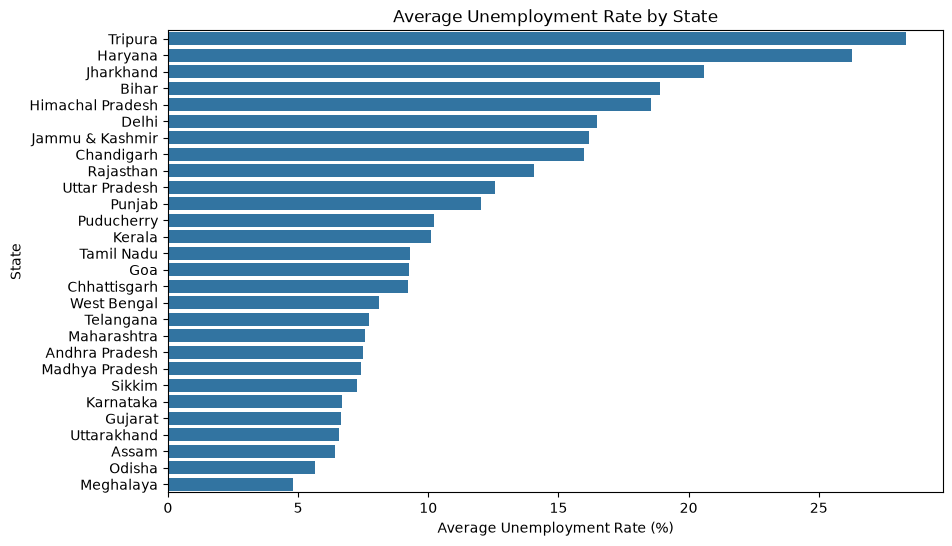

In [12]:
# ===================================================
# 4. STATE-WISE UNEMPLOYMENT ANALYSIS
# ===================================================
# Calculate average unemployment rate per region
state_data = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index()

# Sort states from highest to lowest unemployment rate
state_data = state_data.sort_values(by='Estimated Unemployment Rate (%)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=state_data, x='Estimated Unemployment Rate (%)', y='Region')

plt.title('Average Unemployment Rate by State')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.show()

# 5. Comparing Key Metrics by Year

We compare the unemployment rate and labor participation rate across years using box plots to analyze the impact of COVID-19.

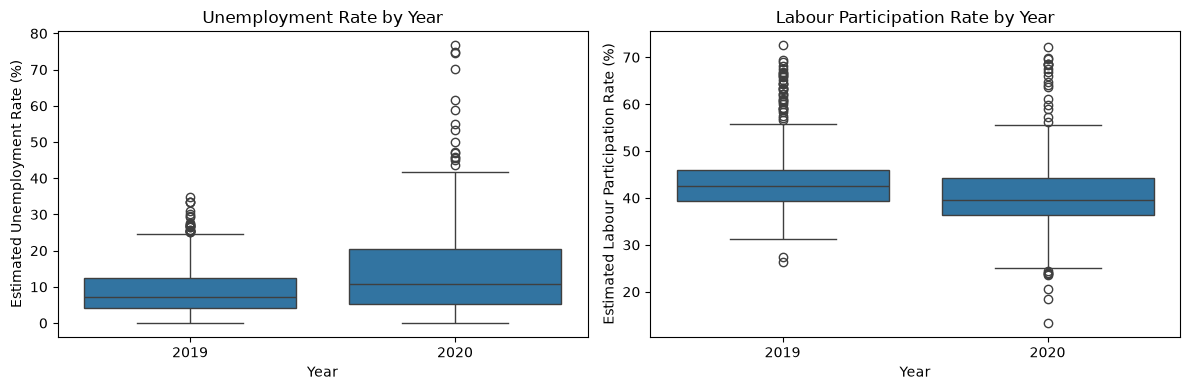

In [13]:
# ===================================================
# 5. COMPARING KEY METRICS BY YEAR
# ===================================================
plt.figure(figsize=(12, 4))

# Plot 1: Unemployment Rate Distribution by Year
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Year', y='Estimated Unemployment Rate (%)')
plt.title('Unemployment Rate by Year')

# Plot 2: Labour Participation Rate Distribution by Year
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Year', y='Estimated Labour Participation Rate (%)')
plt.title('Labour Participation Rate by Year')

plt.tight_layout()
plt.show()